In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

In [2]:
# Load dataset
df = pd.read_csv("../data/processed/final_features.csv")
print("Dataset shape:", df.shape)
print(df.head())

# --- STEP 1: Data Preprocessing ---
# Handle missing values if any
df = df.dropna()

# Select numeric features for clustering
num_features = df.select_dtypes(include=[np.number])

# Standardize data for clustering
scaler = StandardScaler()
scaled_data = scaler.fit_transform(num_features)

Dataset shape: (180519, 56)
    ï»¿type  days_for_shipping_real  days_for_shipment_scheduled  \
0     DEBIT                       3                            4   
1  TRANSFER                       5                            4   
2      CASH                       4                            4   
3     DEBIT                       3                            4   
4   PAYMENT                       2                            4   

   benefit_per_order  sales_per_customer   delivery_status  \
0          91.250000          314.640015  Advance shipping   
1        -249.089996          311.359985     Late delivery   
2        -247.779999          309.720001  Shipping on time   
3          22.860001          304.809998  Advance shipping   
4         134.210007          298.250000  Advance shipping   

   late_delivery_risk  category_id   category_name customer_city  ...  \
0                   0           73  Sporting Goods        Caguas  ...   
1                   1           73  Sporting

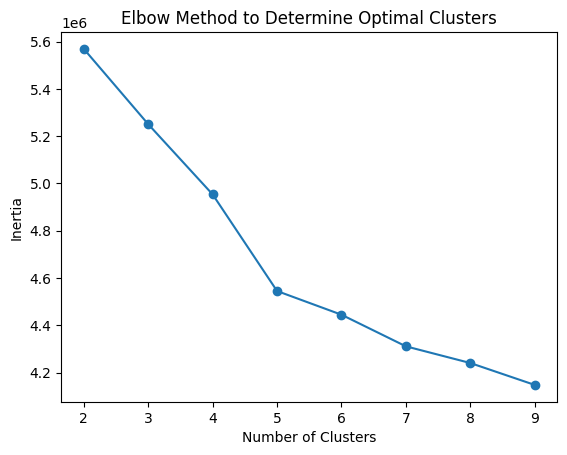

In [3]:

# --- STEP 2: Find optimal number of clusters using Elbow Method ---
inertia = []
for k in range(2, 10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_data)
    inertia.append(kmeans.inertia_)

plt.plot(range(2, 10), inertia, marker='o')
plt.title("Elbow Method to Determine Optimal Clusters")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.show()

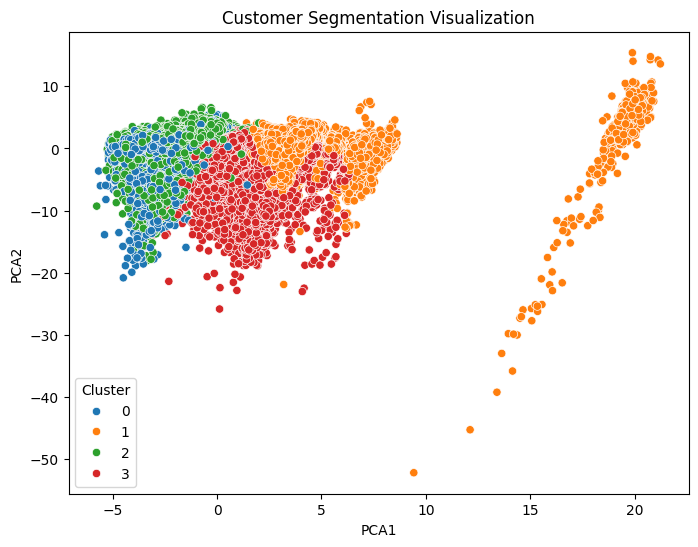

In [4]:
# --- STEP 3: Apply K-Means Clustering ---
optimal_k = 4   # Choose from Elbow plot
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
df['Cluster'] = kmeans.fit_predict(scaled_data)

# --- STEP 4: Visualize Clusters using PCA ---
pca = PCA(n_components=2)
reduced = pca.fit_transform(scaled_data)
df['PCA1'] = reduced[:, 0]
df['PCA2'] = reduced[:, 1]

plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='PCA1', y='PCA2', hue='Cluster', palette='tab10')
plt.title("Customer Segmentation Visualization")
plt.show()


# --- STEP 5: Analyze Clusters for Business Problems ---


### # Problem 1: Targeted Marketing

In [5]:

cluster_summary = df.groupby('Cluster').mean(numeric_only=True)
print("Cluster Summary for Targeted Marketing:\n", cluster_summary)

Cluster Summary for Targeted Marketing:
          days_for_shipping_real  days_for_shipment_scheduled  \
Cluster                                                        
0                      4.105096                     2.470976   
1                      3.501093                     2.949523   
2                      2.754168                     3.512537   
3                      3.496421                     2.902640   

         benefit_per_order  sales_per_customer  late_delivery_risk  \
Cluster                                                              
0                16.842086          148.904026            0.988854   
1                70.198740          338.924357            0.546197   
2                20.862105          148.559296            0.000000   
3                -4.675474          147.408315            0.559310   

         category_id  customer_id  customer_zipcode  department_id   latitude  \
Cluster                                                                 

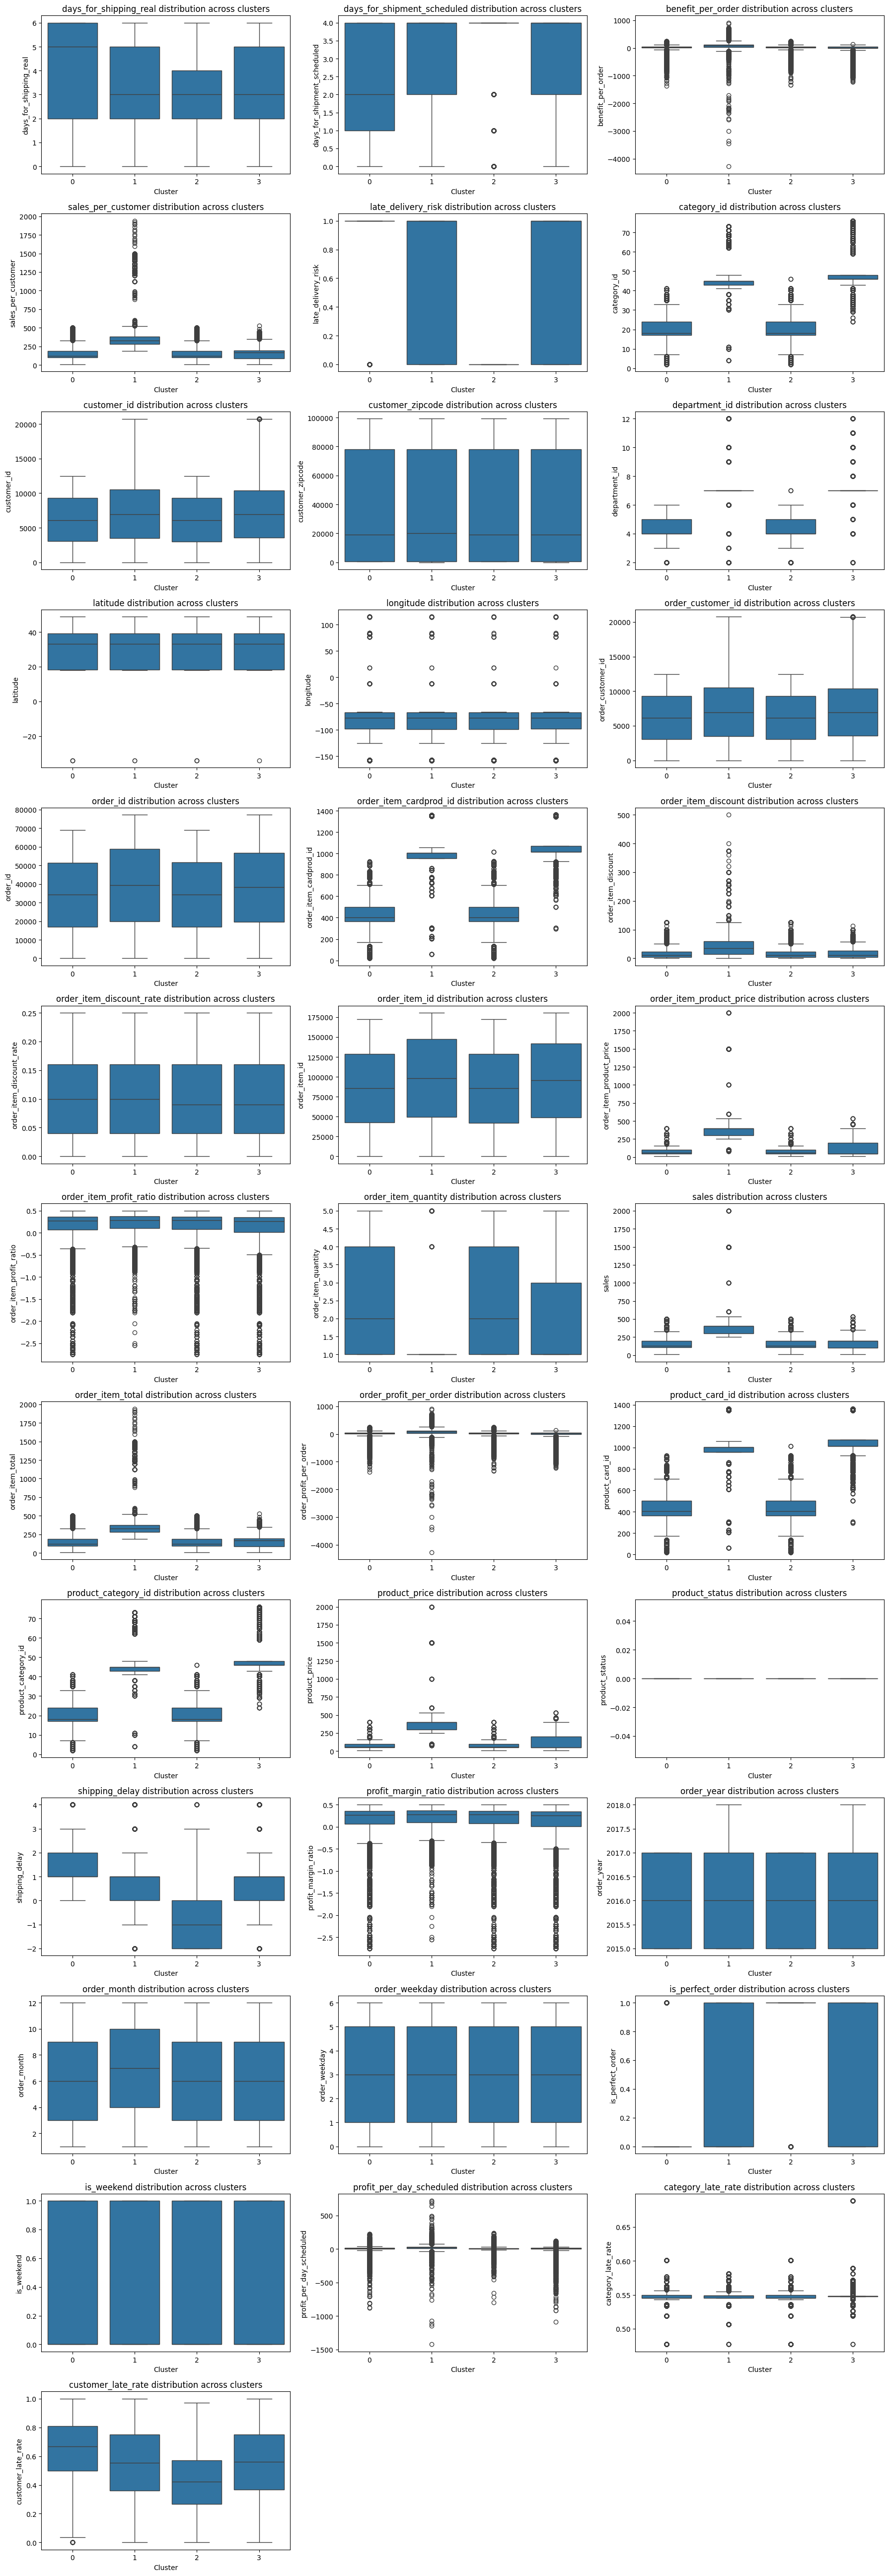

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create subplot grid
n_cols = len(num_features.columns)
n_rows = (n_cols + 2) // 3  # 3 columns per row, adjust as needed

fig, axes = plt.subplots(n_rows, 3, figsize=(18, 4 * n_rows))
axes = axes.flatten() if n_rows > 1 else [axes] if n_cols == 1 else axes

# Plot all features in a single figure
for idx, col in enumerate(num_features.columns):
    if idx < len(axes):
        sns.boxplot(x='Cluster', y=col, data=df, ax=axes[idx])
        axes[idx].set_title(f'{col} distribution across clusters')

# Hide any unused subplots
for idx in range(len(num_features.columns), len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.show()

## Market explansion analysis customer segmentation distribution

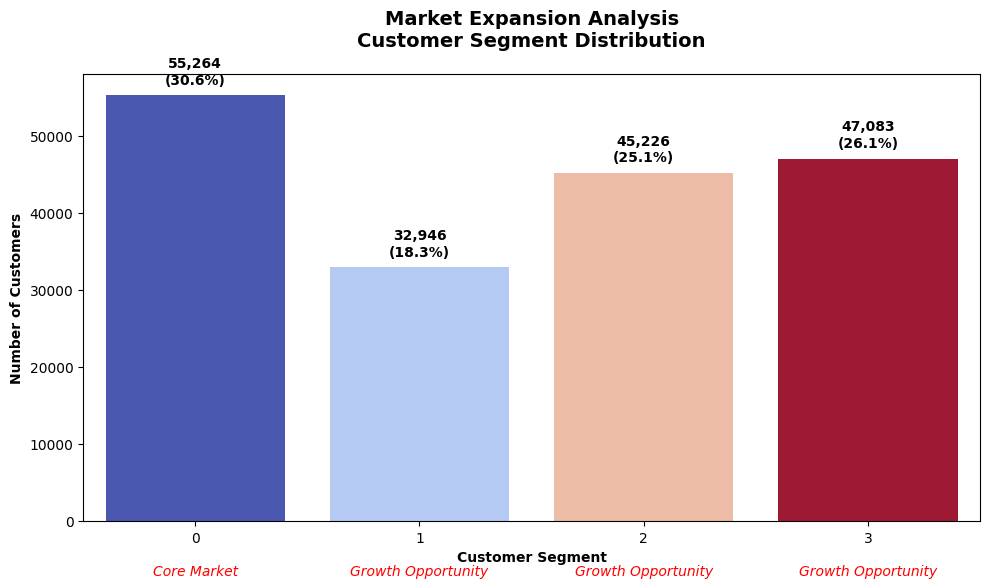

Plot saved as 'customer_segmentation_distribution.png'


In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Styling configuration
plt.style.use('default')
sns.set_palette("husl")

# Problem 4: Enhanced Pricing Strategy Analysis
if 'Annual_Income' in df.columns:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    # Boxplot with enhanced styling
    sns.boxplot(x='Cluster', y='Annual_Income', data=df, ax=ax1)
    ax1.set_title('Pricing Sensitivity Analysis\nAnnual Income by Customer Segment',
                  fontsize=14, fontweight='bold', pad=20)
    ax1.set_xlabel('Customer Segment', fontweight='bold')
    ax1.set_ylabel('Annual Income ($)', fontweight='bold')

    # Add violin plot for better distribution visualization
    sns.violinplot(x='Cluster', y='Annual_Income', data=df, ax=ax2, inner='quartile')
    ax2.set_title('Income Distribution Density\nby Customer Segment',
                  fontsize=14, fontweight='bold', pad=20)
    ax2.set_xlabel('Customer Segment', fontweight='bold')
    ax2.set_ylabel('Annual Income ($)', fontweight='bold')

    plt.tight_layout()
    plt.show()

# Problem 5: Enhanced Customer Distribution
fig, ax = plt.subplots(figsize=(10, 6))
cluster_counts = df['Cluster'].value_counts().sort_index()

# Create enhanced countplot
bars = sns.barplot(x=cluster_counts.index, y=cluster_counts.values,
                   palette='coolwarm', ax=ax, hue=cluster_counts.index, legend=False)

# Customize the plot
ax.set_title('Market Expansion Analysis\nCustomer Segment Distribution',
             fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel('Customer Segment', fontweight='bold')
ax.set_ylabel('Number of Customers', fontweight='bold')

# Add detailed annotations
total_customers = len(df)
for i, (segment, count) in enumerate(cluster_counts.items()):
    percentage = (count / total_customers) * 100
    ax.text(i, count + max(cluster_counts.values)*0.02,
            f'{count:,}\n({percentage:.1f}%)',
            ha='center', va='bottom', fontweight='bold', fontsize=10)

    # Add segment insights based on size
    if percentage > 30:
        insight = "Core Market"
    elif percentage > 15:
        insight = "Growth Opportunity"
    else:
        insight = "Niche Segment"

    ax.text(i, -max(cluster_counts.values)*0.1, insight,
            ha='center', va='top', fontstyle='italic', color='red')

plt.tight_layout()
plt.show()

# Save the figure
fig.savefig("../notebooks/Business results/customer_segmentation_distribution.png")
print("Plot saved as 'customer_segmentation_distribution.png'")

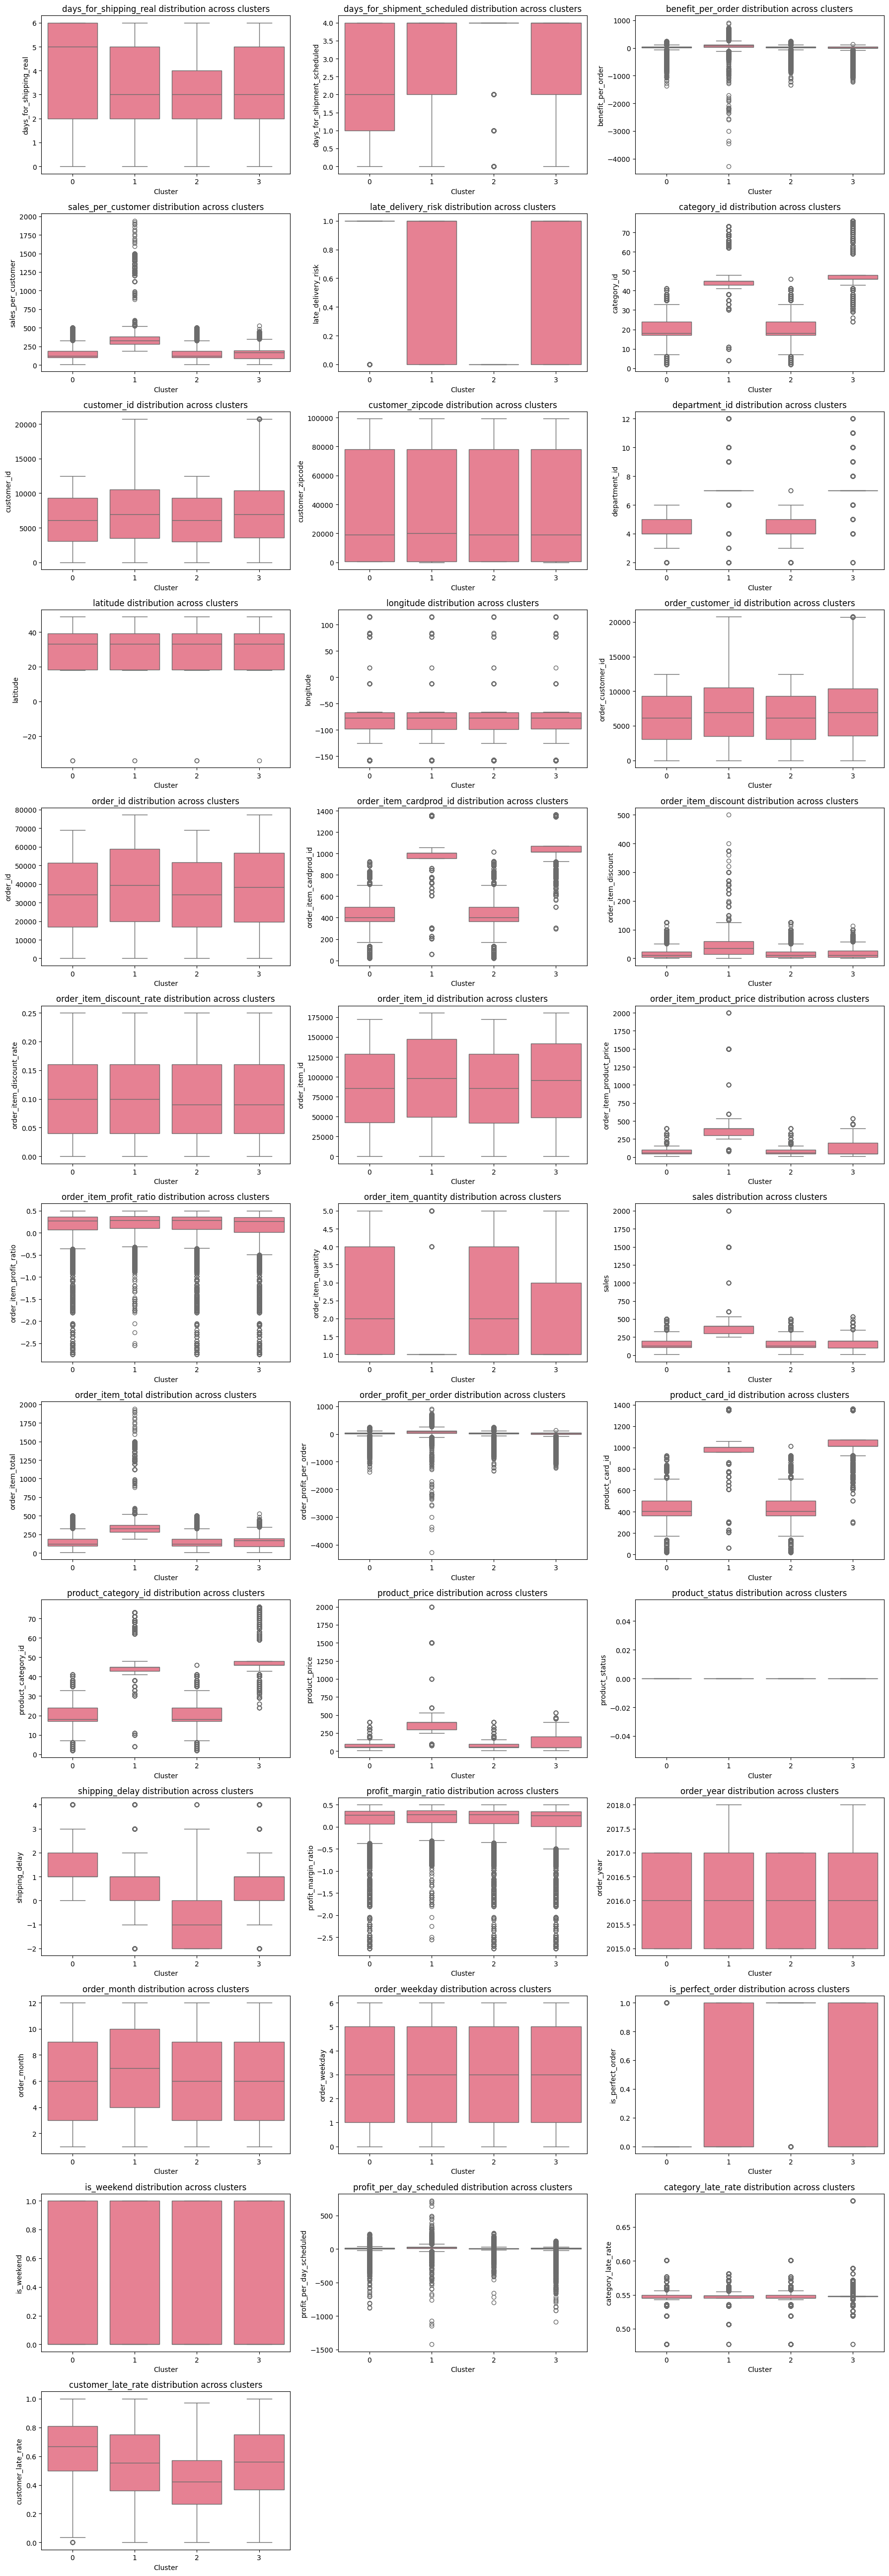

Box plot image saved as 'numeric_features_boxplots.png'


In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create subplot grid
n_cols = len(num_features.columns)
n_rows = (n_cols + 2) // 3  # 3 columns per row, adjust as needed

fig, axes = plt.subplots(n_rows, 3, figsize=(18, 4 * n_rows))
axes = axes.flatten() if n_rows > 1 else [axes] if n_cols == 1 else axes

# Plot all features in a single figure
for idx, col in enumerate(num_features.columns):
    if idx < len(axes):
        sns.boxplot(x='Cluster', y=col, data=df, ax=axes[idx])
        axes[idx].set_title(f'{col} distribution across clusters')

# Hide any unused subplots
for idx in range(len(num_features.columns), len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.show()

# Save the figure
fig.savefig("../notebooks/Business results/numeric_features_boxplots.png")
print("Box plot image saved as 'numeric_features_boxplots.png'")

In [9]:
import os

# Define the directory to search for images
image_dir = '../notebooks/Business results/'

# List common image file extensions
image_extensions = ('.png', '.jpg', '.jpeg', '.gif', '.bmp', '.tiff', '.webp')

# Get all files in the directory
all_files = os.listdir(image_dir)

# Filter for image files
image_files = [f for f in all_files if f.lower().endswith(image_extensions)]

if image_files:
    print("Found image files in the current notebook environment:")
    for img_file in image_files:
        print(f"- {img_file}")
else:
    print("No image files found in the current notebook environment.")

Found image files in the current notebook environment:
- customer_segmentation_distribution.png
- numeric_features_boxplots.png
